<a href="https://colab.research.google.com/github/rkirandatta16-art/Data-analysis-/blob/main/25BDS0101_EXP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded=files.upload()

Saving WineQT.csv to WineQT.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("WineQT.csv")
print(df.head(3))
print(df.tail(3))

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645      

In [5]:
df.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [6]:
print(df.describe())
pd.isna(df).any()

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1143.000000          1143.000000           1143.000000  1143.000000   
mean      0.086933            15.615486             45.914698     0.996730   
std       0.047267            10.250486             32.782130     0.001925   
min       0.012000             1.000000         

,0
fixed acidity,False
volatile acidity,False
citric acid,False
residual sugar,False
chlorides,False
free sulfur dioxide,False
total sulfur dioxide,False
density,False
pH,False
sulphates,False


In [23]:
print("--- Numeric Validity Counts ---")
print(df['quality'].astype(str).str.isnumeric().value_counts())


print("\n--- Rows with Non-Numeric Values ---")
print(df['quality'].loc[df['quality'].astype(str).str.isnumeric() == False])


df[df['quality'] == '?'].count()
ql = df['quality'].loc[df['quality'] != '?'].count()
qmean = ql.astype(int).mean()
df['quality'] = df['quality'].replace('?', qmean).astype(int)

print("\n--- Preview after Data Cleaning ---")
print(df['quality'].head())


--- Numeric Validity Counts ---
quality
True    1143
Name: count, dtype: int64

--- Rows with Non-Numeric Values ---
Series([], Name: quality, dtype: int64)

--- Preview after Data Cleaning ---
0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64


In [24]:
mean = df["quality"].mean()
median = df["quality"].median()
mode = df["quality"].mode()

print("Mean Value:", mean)
print("Median Value:", median)
print("Mode Value:\n", mode)


Mean Value: 5.657042869641295
Median Value: 6.0
Mode Value:
 0    5
Name: quality, dtype: int64


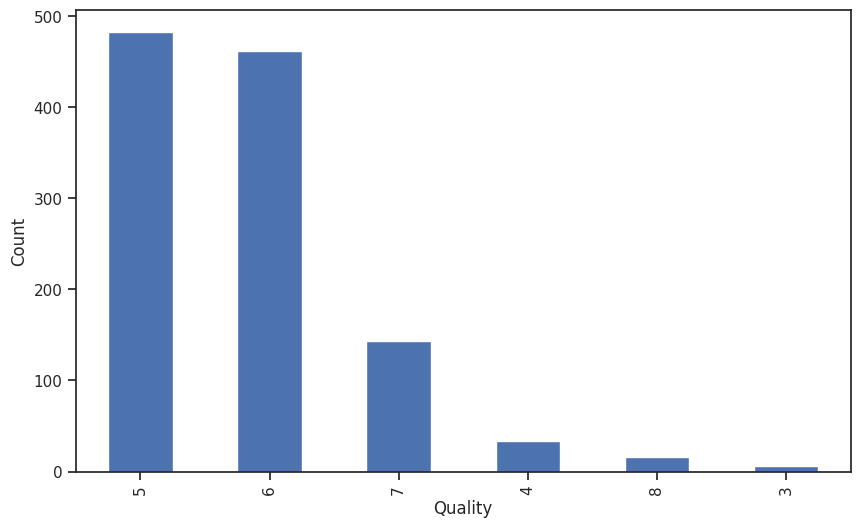

In [45]:
df['quality'].value_counts().nlargest(30).plot(kind='bar', figsize=(10,6))
plt.ylabel('Count')
plt.xlabel('Quality')
plt.show()

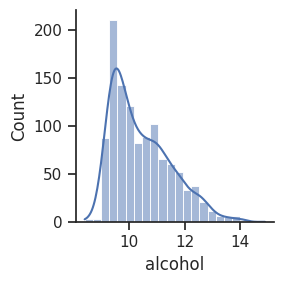

In [44]:
sns.FacetGrid(df).map(sns.histplot, "alcohol", kde=True)
plt.show()


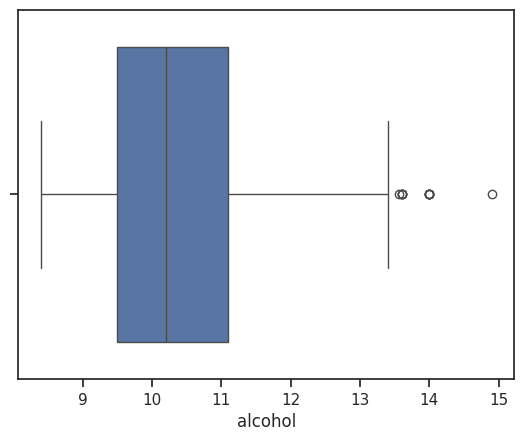

In [43]:
sns.boxplot(x="alcohol", data=df)
plt.show()

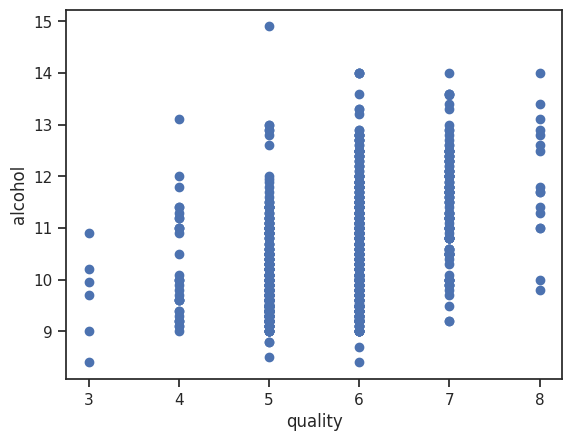

In [42]:
plt.scatter(df["quality"], df["alcohol"])
plt.xlabel("quality")
plt.ylabel("alcohol")
plt.show()


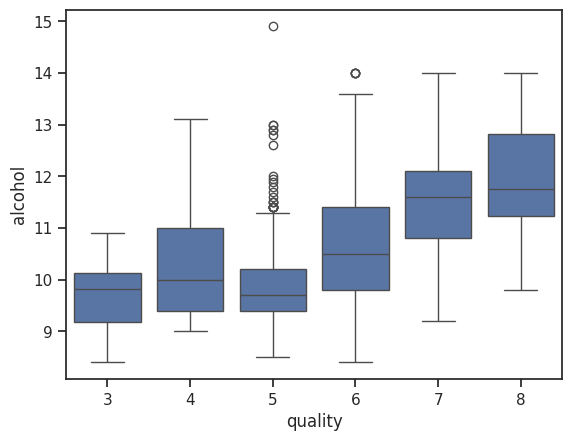

In [40]:
sns.boxplot(x="quality", y="alcohol", data=df)
plt.show()


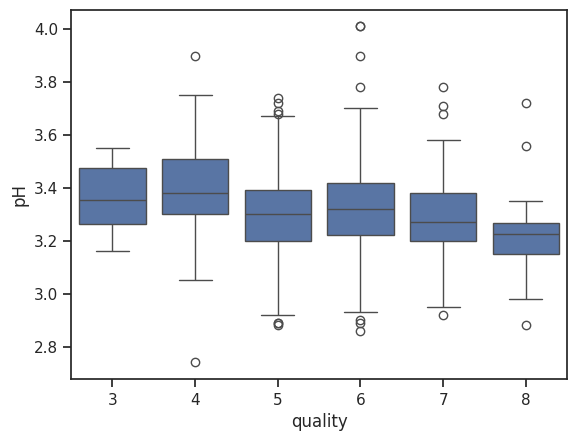

In [41]:
sns.boxplot(x="quality", y="pH", data=df)
plt.show()


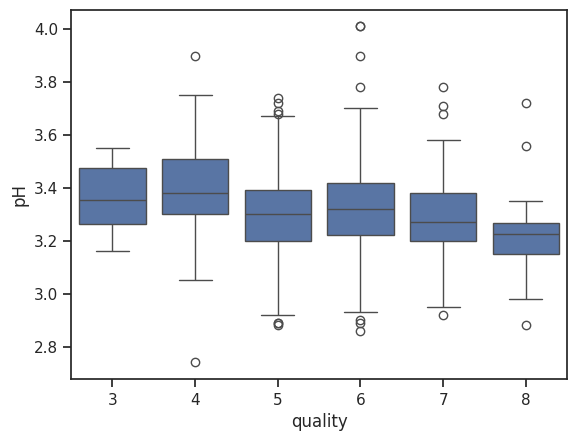

In [39]:
sns.boxplot(x="quality", y="pH", data=df)
plt.show()


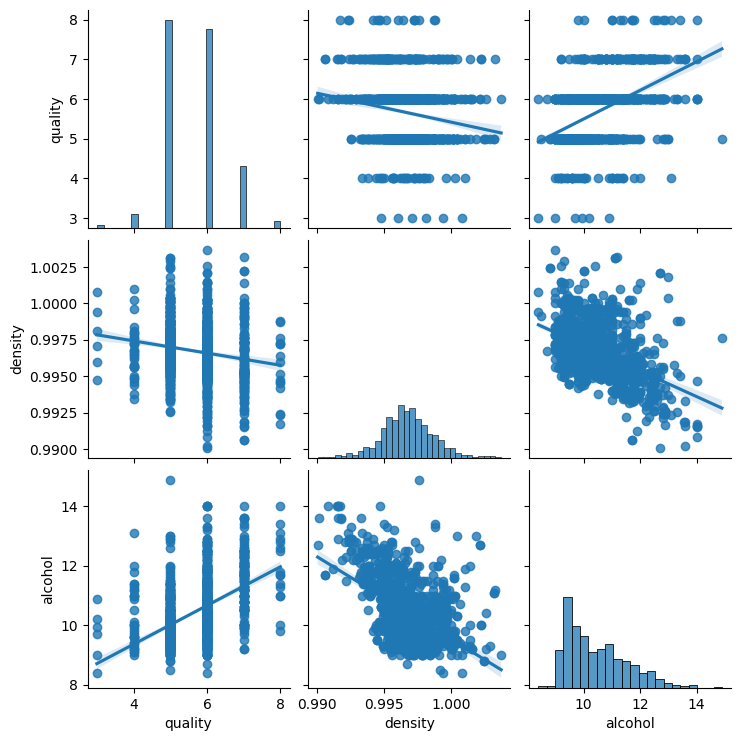

In [29]:
sns.pairplot(df, vars=['quality', 'density', 'alcohol'], kind="reg")
plt.show()


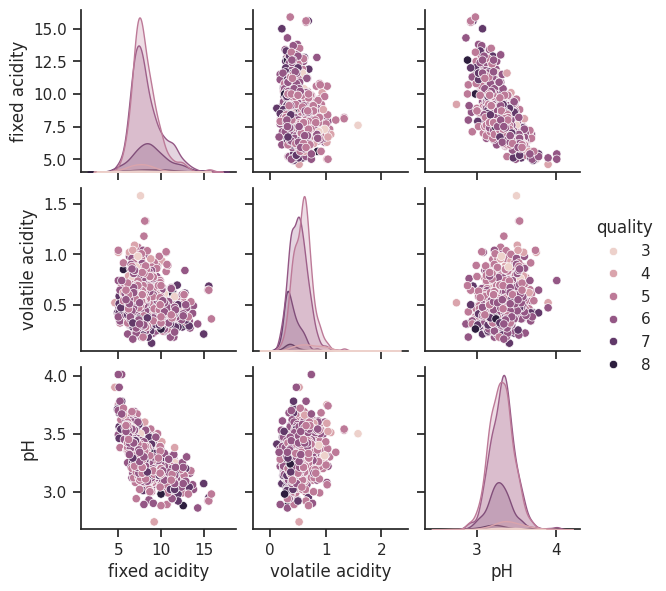

In [30]:
sns.set(style="ticks", color_codes=True)
sns.pairplot(df, height=2, vars=['fixed acidity', 'volatile acidity', 'pH'], hue="quality")
plt.show()


In [34]:
corr = stats.pearsonr(df["alcohol"], df["quality"])
print("p-value:\t", corr)
print("cor:\t\t", corr)


p-value:	 PearsonRResult(statistic=np.float64(0.4848662118085117), pvalue=np.float64(1.9246528151001656e-68))
cor:		 PearsonRResult(statistic=np.float64(0.4848662118085117), pvalue=np.float64(1.9246528151001656e-68))


In [35]:
correlation = df.corr(method='pearson', numeric_only=True)
print(correlation)


                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110617          0.077741     0.036890   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.121970         -0.407394     0.240821   
Id                        -0.275826         -0.007892    -0.139011   

                   

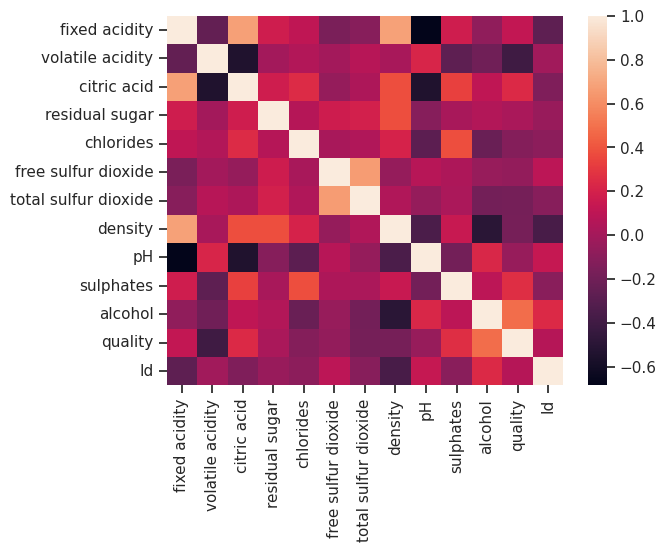

In [38]:

sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns)
plt.show()
